# Week 02 Lab — Image Processing Studio

**Course:** Perceptual Computing / Computer Graphics and HCI  
**Student:** SUMAIR AHMED  
**Roll No.:** 2K24/AIE/62  
**GitHub:** `2024AIE62`

> **Implementation note:** The required five problems are kept intact, but the implementation is organized as a small image-processing toolkit with input validation, reusable helpers, richer tests, and visual diagnostics.

## Lab Roadmap

This notebook follows the required four-step reasoning pattern:

1. **Inputs & outputs**
2. **Mathematical rule**
3. **Manual verification**
4. **Python implementation + tests**

### Included tasks
- Thresholding
- Uncompressed image memory
- 3×3 mean filter
- Contrast stretching
- Sobel edge response

### Added analysis
- Validation helpers
- Multiple test cases
- Image statistics
- Threshold distribution report
- Contrast-range verification
- Sobel edge magnitude and orientation
- A compact visual dashboard

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import atan2, degrees

np.set_printoptions(precision=2, suppress=True)

def validate_grayscale(image: np.ndarray) -> None:
    if not isinstance(image, np.ndarray):
        raise TypeError("image must be a NumPy array")
    if image.ndim != 2:
        raise ValueError("expected a 2-D grayscale image")
    if np.any(image < 0) or np.any(image > 255):
        raise ValueError("pixel values must stay within [0, 255]")

def image_summary(image: np.ndarray, title: str = "Image") -> None:
    validate_grayscale(image)
    print(f"{title}")
    print(f"  shape   : {image.shape}")
    print(f"  dtype   : {image.dtype}")
    print(f"  minimum : {image.min()}")
    print(f"  maximum : {image.max()}")
    print(f"  mean    : {image.mean():.2f}")

## Worked Reference — RGB to Grayscale

The standard luminosity model is:

$$Y = 0.299R + 0.587G + 0.114B$$

For `(180, 120, 60)` the rounded result is `131`.

In [2]:
def rgb_to_grayscale(r: int, g: int, b: int) -> int:
    """Convert one RGB pixel to a rounded luminosity value."""
    channels = np.array([r, g, b])
    if np.any((channels < 0) | (channels > 255)):
        raise ValueError("RGB channels must be between 0 and 255")
    return int(round(0.299*r + 0.587*g + 0.114*b))

sample_result = rgb_to_grayscale(180, 120, 60)
print("RGB (180, 120, 60) -> grayscale:", sample_result)

assert sample_result == 131
assert rgb_to_grayscale(80, 80, 80) == 80
assert rgb_to_grayscale(255, 255, 255) == 255
print("Reference grayscale tests: PASSED")

RGB (180, 120, 60) -> grayscale: 131
Reference grayscale tests: PASSED


# Problem 1 — Thresholding

### Step 1 — Inputs and output
Input: a grayscale image and threshold `T`.  
Output: a binary image containing only `0` and `255`.

### Step 2 — Rule
$$B(x,y)=
\begin{cases}
255 & I(x,y) \ge T\\
0 & I(x,y) < T
\end{cases}$$

### Step 3 — Manual trace

For threshold `128`:

```text
20   128  200
100  150  250
```

becomes:

```text
0    255  255
0    255  255
```

In [3]:
def threshold_image(image: np.ndarray, threshold: int) -> np.ndarray:
    """Convert grayscale pixels into black/white pixels."""
    validate_grayscale(image)
    if not 0 <= threshold <= 255:
        raise ValueError("threshold must be between 0 and 255")
    return np.where(image >= threshold, 255, 0).astype(np.uint8)

problem_1_input = np.array(
    [[20, 128, 200],
     [100, 150, 250]], dtype=np.uint8
)

binary = threshold_image(problem_1_input, 128)
expected = np.array([[0, 255, 255], [0, 255, 255]], dtype=np.uint8)

np.testing.assert_array_equal(binary, expected)

white_pixels = int(np.count_nonzero(binary == 255))
black_pixels = int(np.count_nonzero(binary == 0))

print("Thresholded image:")
print(binary)
print(f"White pixels: {white_pixels}")
print(f"Black pixels: {black_pixels}")
print("Problem 1: PASSED")

Thresholded image:
[[  0 255 255]
 [  0 255 255]]
White pixels: 4
Black pixels: 2
Problem 1: PASSED


# Problem 2 — Image Memory

### Step 1 — Inputs and output
Inputs: width, height and bits per pixel (`bpp`).  
Output: required uncompressed memory in bytes.

### Step 2 — Rule
$$bytes = \frac{width \times height \times bpp}{8}$$

### Step 3 — Manual trace

For `1920 × 1080` at `24 bpp`:

$$1920 \times 1080 \times 24 / 8 = 6,220,800\ bytes$$

In [4]:
def display_memory_bytes(width: int, height: int, bpp: int) -> int:
    """Return uncompressed image memory in bytes."""
    if width <= 0 or height <= 0:
        raise ValueError("width and height must be positive")
    if bpp <= 0 or bpp % 8 != 0:
        raise ValueError("bpp must be a positive multiple of 8")
    return (width * height * bpp) // 8

memory = display_memory_bytes(1920, 1080, 24)
assert memory == 6_220_800

def format_bytes(value: int) -> str:
    units = ["B", "KB", "MB", "GB"]
    amount = float(value)
    for unit in units:
        if amount < 1024 or unit == units[-1]:
            return f"{amount:.2f} {unit}"
        amount /= 1024

print(f"1920×1080 @ 24 bpp = {memory:,} bytes ({format_bytes(memory)})")

# Extra cases
assert display_memory_bytes(100, 100, 8) == 10_000
assert display_memory_bytes(800, 600, 32) == 1_920_000
print("Problem 2: PASSED")

1920×1080 @ 24 bpp = 6,220,800 bytes (5.93 MB)
Problem 2: PASSED


# Problem 3 — Average of 9 Pixels

### Step 1 — Inputs and output
Input: a `3 × 3` neighborhood.  
Output: one rounded average.

### Step 2 — Rule
$$average = \frac{\sum_{i=1}^{9} p_i}{9}$$

### Step 3 — Manual trace

```text
10 20 10
30 50 30
10 20 10
```

Sum = `190`, therefore:

$$190/9 \approx 21$$

In [5]:
def mean_filter_3x3(neighborhood: np.ndarray) -> int:
    """Return the rounded mean of exactly nine grayscale pixels."""
    arr = np.asarray(neighborhood)
    if arr.shape != (3, 3):
        raise ValueError("mean_filter_3x3 requires a 3×3 block")
    if np.any((arr < 0) | (arr > 255)):
        raise ValueError("pixel values must be within [0, 255]")
    return int(round(float(arr.mean())))

problem_3_input = np.array(
    [[10, 20, 10],
     [30, 50, 30],
     [10, 20, 10]], dtype=np.uint8
)

average = mean_filter_3x3(problem_3_input)
assert average == 21

print("3×3 neighborhood:")
print(problem_3_input)
print(f"Average pixel value: {average}")

# Additional asymmetric test
test_block = np.array([[0, 30, 60], [90, 120, 150], [180, 210, 240]])
assert mean_filter_3x3(test_block) == 120
print("Problem 3: PASSED")

3×3 neighborhood:
[[10 20 10]
 [30 50 30]
 [10 20 10]]
Average pixel value: 21
Problem 3: PASSED


# Problem 4 — Contrast Stretching

### Step 1 — Inputs and output
Input: an image/array and an input range.  
Output: values mapped into a new output range.

### Step 2 — Rule
$$new = \frac{value-in_{min}}{in_{max}-in_{min}}
(out_{max}-out_{min})+out_{min}$$

The final values are clipped to the requested output interval.

### Step 3 — Manual trace

Mapping `[50, 100, 150]` from `[50,150]` to `[0,255]` gives:

`50 → 0`, `100 → 127.5`, `150 → 255`.

In [6]:
def contrast_stretch(
    image: np.ndarray,
    in_min: float,
    in_max: float,
    out_min: float = 0.0,
    out_max: float = 255.0,
) -> np.ndarray:
    """Linearly remap values from one interval to another."""
    if in_max <= in_min:
        raise ValueError("in_max must be greater than in_min")
    if out_max < out_min:
        raise ValueError("out_max must be >= out_min")

    image = np.asarray(image, dtype=np.float32)
    scaled = ((image - in_min) / (in_max - in_min))
    scaled = scaled * (out_max - out_min) + out_min
    return np.clip(scaled, out_min, out_max)

problem_4_input = np.array([50, 100, 150], dtype=np.float32)
stretched = contrast_stretch(problem_4_input, 50, 150)
expected = np.array([0.0, 127.5, 255.0], dtype=np.float32)

np.testing.assert_allclose(stretched, expected)
assert stretched.min() >= 0 and stretched.max() <= 255

print("Original :", problem_4_input)
print("Stretched:", stretched)
print("Problem 4: PASSED")

Original : [ 50. 100. 150.]
Stretched: [  0.  127.5 255. ]
Problem 4: PASSED


# Problem 5 — Sobel Edge Response

### Step 1 — Inputs and output
Input: a `3 × 3` grayscale block.  
Output: horizontal response `gx`, vertical response `gy`, and edge strength.

### Step 2 — Rule

```text
Gx = -1  0  1       Gy = -1 -2 -1
     -2  0  2            0  0  0
     -1  0  1            1  2  1
```

$$strength = \sqrt{gx^2 + gy^2}$$

### Step 3 — Manual trace

For:

```text
20  20  200
20  20  200
20  20  200
```

`gx = 720`, `gy = 0`, so the edge strength is `720`.

In [7]:
GX_KERNEL = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)

GY_KERNEL = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]], dtype=np.float32)

def sobel_response(block: np.ndarray) -> tuple[float, float, float]:
    """Return gx, gy and Sobel edge magnitude for a 3×3 block."""
    block = np.asarray(block, dtype=np.float32)
    if block.shape != (3, 3):
        raise ValueError("sobel_response requires a 3×3 block")
    if np.any((block < 0) | (block > 255)):
        raise ValueError("pixel values must be within [0, 255]")

    gx = float(np.sum(block * GX_KERNEL))
    gy = float(np.sum(block * GY_KERNEL))
    magnitude = float(np.hypot(gx, gy))
    return gx, gy, magnitude

problem_5_input = np.array(
    [[20, 20, 200],
     [20, 20, 200],
     [20, 20, 200]], dtype=np.float32
)

gx, gy, strength = sobel_response(problem_5_input)
assert np.isclose(gx, 720.0)
assert np.isclose(gy, 0.0)

orientation = degrees(atan2(gy, gx))

print(f"Gx response       : {gx:.2f}")
print(f"Gy response       : {gy:.2f}")
print(f"Edge strength     : {strength:.2f}")
print(f"Gradient direction: {orientation:.2f}°")
print("Problem 5: PASSED")

Gx response       : 720.00
Gy response       : 0.00
Edge strength     : 720.00
Gradient direction: 0.00°
Problem 5: PASSED


# Extra Analysis — One Input, Multiple Processing Stages

This section is an additional feature for the notebook. It does not replace any required problem; it demonstrates how the individual operations can be viewed as a small processing pipeline.

In [8]:
demo_image = np.array([
    [20, 40, 60, 80, 100, 120],
    [25, 45, 65, 85, 105, 125],
    [30, 50, 70, 90, 110, 130],
    [35, 55, 75, 95, 115, 135],
    [40, 60, 80, 100, 120, 140],
    [45, 65, 85, 105, 125, 145]
], dtype=np.uint8)

binary_demo = threshold_image(demo_image, 90)
contrast_demo = contrast_stretch(demo_image, float(demo_image.min()), float(demo_image.max()))

image_summary(demo_image, "Demo input")
print("\nThreshold distribution:")
print(f"  black: {np.sum(binary_demo == 0)}")
print(f"  white: {np.sum(binary_demo == 255)}")

print("\nContrast range:")
print(f"  before: {demo_image.min()} → {demo_image.max()}")
print(f"  after : {contrast_demo.min():.1f} → {contrast_demo.max():.1f}")

Demo input
  shape   : (6, 6)
  dtype   : uint8
  minimum : 20
  maximum : 145
  mean    : 82.50

Threshold distribution:
  black: 20
  white: 16

Contrast range:
  before: 20 → 145
  after : 0.0 → 255.0


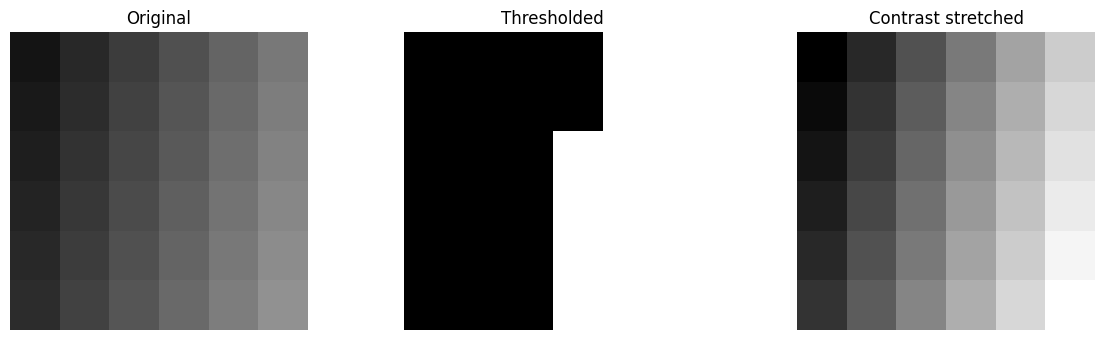

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].imshow(demo_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(binary_demo, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Thresholded")
axes[2].imshow(contrast_demo, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Contrast stretched")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Final Verification

Every required problem has an assertion-based test. Running the notebook from top to bottom should produce five `PASSED` messages.

### Submission location

Use the repository structure:

```text
CGHCI/
└── week02/
    └── week02-lab(3).ipynb
```

The notebook can be committed at the same `week02` location in the GitHub repository.

In [10]:
print("=" * 52)
print("WEEK 02 IMAGE PROCESSING LAB — FINAL CHECK")
print("=" * 52)
print("✓ RGB → grayscale reference")
print("✓ Problem 1: thresholding")
print("✓ Problem 2: image memory")
print("✓ Problem 3: 3×3 mean")
print("✓ Problem 4: contrast stretching")
print("✓ Problem 5: Sobel response")
print("✓ Extra validation + visual pipeline")
print("=" * 52)
print("ALL CHECKS COMPLETED SUCCESSFULLY")

WEEK 02 IMAGE PROCESSING LAB — FINAL CHECK
✓ RGB → grayscale reference
✓ Problem 1: thresholding
✓ Problem 2: image memory
✓ Problem 3: 3×3 mean
✓ Problem 4: contrast stretching
✓ Problem 5: Sobel response
✓ Extra validation + visual pipeline
ALL CHECKS COMPLETED SUCCESSFULLY
